In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import os

# --- PATH SETUP ---
zip_dis_path = "/content/drive/MyDrive/Colab Notebooks (1)/Chilli Plant Dataset/Chili Leaf Disease Original Dataset.zip"
if os.path.exists(zip_dis_path):
    print("Zip file mil gayi! Extracting...")
    !unzip -q "{zip_dis_path}" -d "/content/disease_data"
    print("Unzipping Successful!")
else:
    print("ERROR: Zip file Not founded. Check your path.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Zip file mil gayi! Extracting...
Unzipping Successful!


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.utils import class_weight
import numpy as np
import os

# --- 1. DATA PREPARATION ---
path_dis = '/content/disease_data/Chili Leaf Disease Original Dataset'

# Note: Rescale=1./255 hata diya hai kyunki EfficientNet preprocess_input khud handle karta hai
datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    zoom_range=0.2,
    validation_split=0.2
)

train_generator = datagen.flow_from_directory(
    path_dis, target_size=(224, 224), batch_size=32, subset='training', shuffle=True
)

val_generator = datagen.flow_from_directory(
    path_dis, target_size=(224, 224), batch_size=32, subset='validation', shuffle=False
)

# --- 2. CLASS WEIGHTS CALCULATION (Crucial for fixing bias) ---
weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)
cw_dict = dict(enumerate(weights))
print(f"Class Weights applied: {cw_dict}")

# --- 3. MODEL BUILDING ---
base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dense(512, activation='relu')(x) # Increased neurons
x = Dropout(0.5)(x)
# Label Smoothing added to prevent overconfidence
predictions = Dense(train_generator.num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

# --- 4. TRAINING STAGE 1: Top Layers ---
model.compile(optimizer=Adam(learning_rate=1e-3),
              loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
              metrics=['accuracy'])

print("\nStage 1: Training Top Layers...")
model.fit(train_generator, validation_data=val_generator, epochs=5, class_weight=cw_dict)

# --- 5. TRAINING STAGE 2: Fine-Tuning ---
base_model.trainable = True
# Freeze first 100 layers, unfreeze the rest for specific leaf features
for layer in base_model.layers[:100]:
    layer.trainable = False

model.compile(optimizer=Adam(learning_rate=1e-5),
              loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
              metrics=['accuracy'])

callbacks = [
    EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=1e-7)
]

print("\nStage 2: Fine-tuning for accuracy...")
model.fit(train_generator, validation_data=val_generator,
          epochs=10, callbacks=callbacks, class_weight=cw_dict)

# Save as .keras (Modern format)
model.save('/content/chilli_disease_fixed.keras')
print("Model Saved Successfully!")

Found 1487 images belonging to 6 classes.
Found 369 images belonging to 6 classes.
Class Weights applied: {0: np.float64(1.9826666666666666), 1: np.float64(1.7210648148148149), 2: np.float64(0.7310717797443461), 3: np.float64(0.6752951861943688), 4: np.float64(0.6961610486891385), 5: np.float64(1.5886752136752136)}

Stage 1: Training Top Layers...
Epoch 1/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 200s 4s/step - accuracy: 0.7781 - loss: 1.2400 - val_accuracy: 0.8076 - val_loss: 0.9318
Epoch 2/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 182s 4s/step - accuracy: 0.8951 - loss: 0.8508 - val_accuracy: 0.8916 - val_loss: 0.8406
Epoch 3/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 176s 4s/step - accuracy: 0.9059 - loss: 0.7872 - val_accuracy: 0.9106 - val_loss: 0.7288
Epoch 4/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 189s 4s/step - accuracy: 0.9301 - loss: 0.7305 - val_accuracy: 0.9268 - val_loss: 0.6927
Epoch 5/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 175s 4s/step - accuracy: 0.9267 - loss: 0.7286 - val_accuracy: 0.8997 - val_loss: 0.7445

Stage 2: Fine-tunin

In [ ]:
def test_final_model(img_path):
    img = tf.keras.preprocessing.image.load_img(img_path, target_size=(224, 224))
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array) # EfficientNet specific scaling

    preds = model.predict(img_array)[0]
    class_idx = np.argmax(preds)
    class_labels = list(train_generator.class_indices.keys())

    print("\n--- Model Output ---")
    for i, label in enumerate(class_labels):
        print(f"{label}: {preds[i]*100:.2f}%")

    print(f"\nFINAL PREDICTION: {class_labels[class_idx]} ({preds[class_idx]*100:.2f}%)")

# Test on your problematic image
test_final_model("/content/curl disease.jpg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 380ms/step

--- Model Output ---
Bacterial Spot: 4.50%
Cercospora Leaf Spot: 71.31%
Curl Virus: 14.84%
Healthy Leaf: 0.64%
Nutrition Deficiency: 7.03%
White spot: 1.67%

FINAL PREDICTION: Cercospora Leaf Spot (71.31%)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step


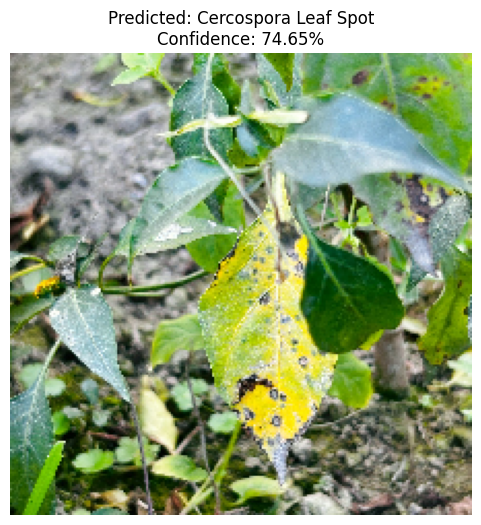

--- Analysis Result ---
Detected Category: Cercospora Leaf Spot
Confidence Level: 74.65%
Severity Level: MEDIUM
Recommendation: Immediate inspection suggested for Cercospora Leaf Spot.


In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.efficientnet import preprocess_input

# 1. Provide the path to the image you want to test
# You can upload a new photo to Colab or pick one from the dataset
test_image_path = "/content/Cercospora Leaf Spot00003.JPG"


def test_model_performance(img_path):
    # Load and resize image to 224x224
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)

    # Preprocess the image exactly like the training data
    img_array = preprocess_input(img_array)

    # Get predictions
    predictions = model.predict(img_array)[0]
    class_index = np.argmax(predictions)

    # Get labels from your train_generator
    class_labels = list(train_generator.class_indices.keys())
    result_label = class_labels[class_index]
    confidence = predictions[class_index] * 100

    # Plot the result
    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Predicted: {result_label}\nConfidence: {confidence:.2f}%")
    plt.show()

    print(f"--- Analysis Result ---")
    print(f"Detected Category: {result_label}")
    print(f"Confidence Level: {confidence:.2f}%")

    # Severity assessment logic
    if result_label.lower() == 'healthy leaf':
        print("Recommendation: No action needed. Maintain regular monitoring.")
    else:
        severity = "HIGH" if confidence > 85 else "MEDIUM" if confidence > 60 else "LOW"
        print(f"Severity Level: {severity}")
        print(f"Recommendation: Immediate inspection suggested for {result_label}.")

# Run the test
test_model_performance(test_image_path)

In [ ]:
print(train_generator.class_indices)

{'Bacterial Spot': 0, 'Cercospora Leaf Spot': 1, 'Curl Virus': 2, 'Healthy Leaf': 3, 'Nutrition Deficiency': 4, 'White spot': 5}


In [ ]:
import os

# Dataset ka path (Corrected as per your previous screenshots)
dataset_path = '/content/disease_data/Chili Leaf Disease Original Dataset'

if os.path.exists(dataset_path):
    print("--- Image Count per Category ---")
    total_images = 0

    # Har folder ko check karna
    for folder in sorted(os.listdir(dataset_path)):
        folder_path = os.path.join(dataset_path, folder)

        # Sirf folders ko scan karein
        if os.path.isdir(folder_path):
            # Sirf image files (.jpg, .png, .jpeg) count karein
            images = [f for f in os.listdir(folder_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
            count = len(images)
            print(f"{folder}: {count}")
            total_images += count

    print("---------------------------------")
    print(f"Total Images in Dataset: {total_images}")
else:
    print(f"Error: Path '{dataset_path}' nahi mila. Please check folders.")

--- Image Count per Category ---
Bacterial Spot: 156
Cercospora Leaf Spot: 180
Curl Virus: 423
Healthy Leaf: 458
Nutrition Deficiency: 444
White spot: 195
---------------------------------
Total Images in Dataset: 1856
